### Import Libraries

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

### Read & Explore Data

In [42]:
df=pd.read_csv('/content/modified_placement_data.csv')

In [64]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


In [44]:
df.shape

(100, 3)

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [76]:
df.isnull().sum()

,0
cgpa,0
iq,0
placement,0


In [62]:
df['cgpa'].fillna(df['cgpa'].mean(),inplace=True)

/tmp/ipykernel_4628/815226.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['cgpa'].fillna(df['cgpa'].mean(),inplace=True)


Unnamed is extra column so remove it

In [65]:
df=df.iloc[:,0:]
# : means all, :1 from one excluding unnamed

In [77]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,Yes
1,5.9,106.0,No
2,5.3,121.0,No
3,7.4,132.0,Yes
4,5.8,142.0,No


Convert , to .

Then convert column to float

In [50]:
df['cgpa'] = df['cgpa'].str.replace(',', '.', regex=False)
df['cgpa'] = df['cgpa'].astype(float)

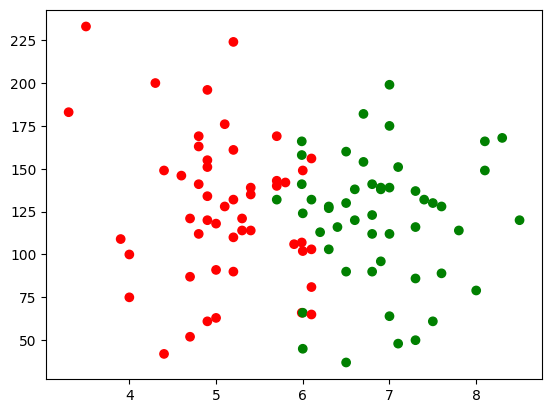

In [67]:
colors = df['placement'].map({'Yes': 'green', 'No': 'red'})
plt.scatter(df['cgpa'], df['iq'], c=colors)

Get the input and output variables

In [83]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

In [97]:
x=df.iloc[:,0:1]
y=df.iloc[:,-1]

In [99]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)

In [100]:
y.shape

(100,)

Split the data into 90% train and rest in test

In [101]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1)

Scale the data for Nr Distribution

In [102]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)

In [103]:
X_test_scaled=scaler.fit_transform(X_test)

In [104]:
from sklearn.linear_model import LogisticRegression

lr=LogisticRegression()
lr.fit(X_train_scaled,y_train)

LogisticRegression()

In [105]:
lr.predict(X_test_scaled)

array([0, 1, 0, 1, 1, 1, 1, 0, 0, 0])

In [106]:
y_test

array([1, 1, 0, 1, 1, 1, 1, 0, 0, 0])

In [107]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,lr.predict(X_test_scaled))

0.9

### See the decision boundary

y must be a NumPy array. Found <class 'pandas.core.series.Series'>
write y_train.to_numpy()

<Axes: >

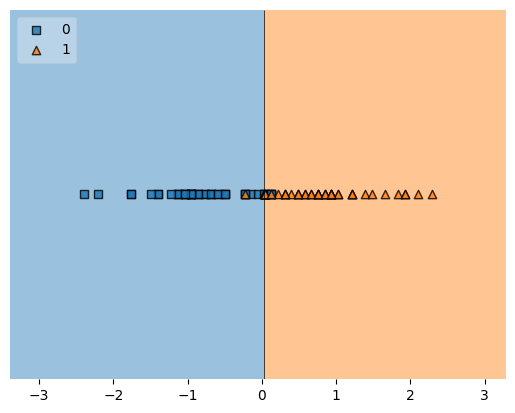

In [111]:
from mlxtend.plotting import plot_decision_regions
import numpy as np

plot_decision_regions(X_train_scaled, y_train, clf=lr, legend=2)

Create pickle in write binary mode

In [112]:
import pickle

In [114]:
pickle.dump(lr,open('model.pkl','wb'))

In [118]:
sample_cgpa = 7.0
# Reshape to 2D array and scale the sample CGPA
sample_cgpa_scaled = scaler.transform(np.array([[sample_cgpa]]))

# Make a prediction
prediction = lr.predict(sample_cgpa_scaled)

# Print the prediction
print(f"Prediction for CGPA {sample_cgpa}: {prediction}")

# Optionally, you can also print the probability
prediction_proba = lr.predict_proba(sample_cgpa_scaled)
print(f"Prediction probabilities for CGPA {sample_cgpa}: {prediction_proba}")

Prediction for CGPA 7.0: [1]
Prediction probabilities for CGPA 7.0: [[0.1281363 0.8718637]]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
